# Notebook 03 — Feature Engineering
**CIS6035 IHMS — Somerset Mirissa Beach Hotel**

Engineer temporal, lag, and interaction features for documentation and
potential regression baseline comparison. ARIMA/SARIMA/Prophet use their
own feature representations, but this analysis informs rationale.

Features engineered:
- Calendar: `day_of_week`, `day_of_year`, `week_of_year`, `quarter`
- Seasonal: `is_peak_season` (Dec/Jan)
- Lag features: `lag_7`, `lag_14`, `lag_30`
- Rolling means: `rolling_mean_7`, `rolling_mean_30`
- Interaction: `weekend_x_peak`
- Distance: `days_since_holiday`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../data/splits', exist_ok=True)
os.makedirs('../docs/figures', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
df = pd.read_csv('../data/hotel_data.csv')
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
df = df.sort_values('date').set_index('date')
print(df.shape)

(1096, 8)


In [3]:
# Calendar features
df['day_of_week']  = df.index.dayofweek          # 0=Monday
df['day_of_year']  = df.index.dayofyear
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['quarter']      = df.index.quarter

# Peak season: Dec (12) and Jan (1)
df['is_peak_season'] = df.index.month.isin([12, 1]).astype(int)

# Lag features
df['lag_7']  = df['occupancy_rate'].shift(7)
df['lag_14'] = df['occupancy_rate'].shift(14)
df['lag_30'] = df['occupancy_rate'].shift(30)

# Rolling means (trailing window — no look-ahead)
df['rolling_mean_7']  = df['occupancy_rate'].shift(1).rolling(7).mean()
df['rolling_mean_30'] = df['occupancy_rate'].shift(1).rolling(30).mean()

# Interaction feature
df['weekend_x_peak'] = df['is_weekend'] * df['is_peak_season']

# Days since last holiday
holiday_dates = df.index[df['is_holiday'] == 1]
def days_since_holiday(date):
    past = holiday_dates[holiday_dates <= date]
    return (date - past[-1]).days if len(past) > 0 else np.nan

df['days_since_holiday'] = [days_since_holiday(d) for d in df.index]

print('Engineered features:')
print([c for c in df.columns if c not in ['total_rooms','booked_rooms','occupancy_rate','month','is_weekend','season','is_holiday','revenue']])

Engineered features:
['day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_peak_season', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'weekend_x_peak', 'days_since_holiday']


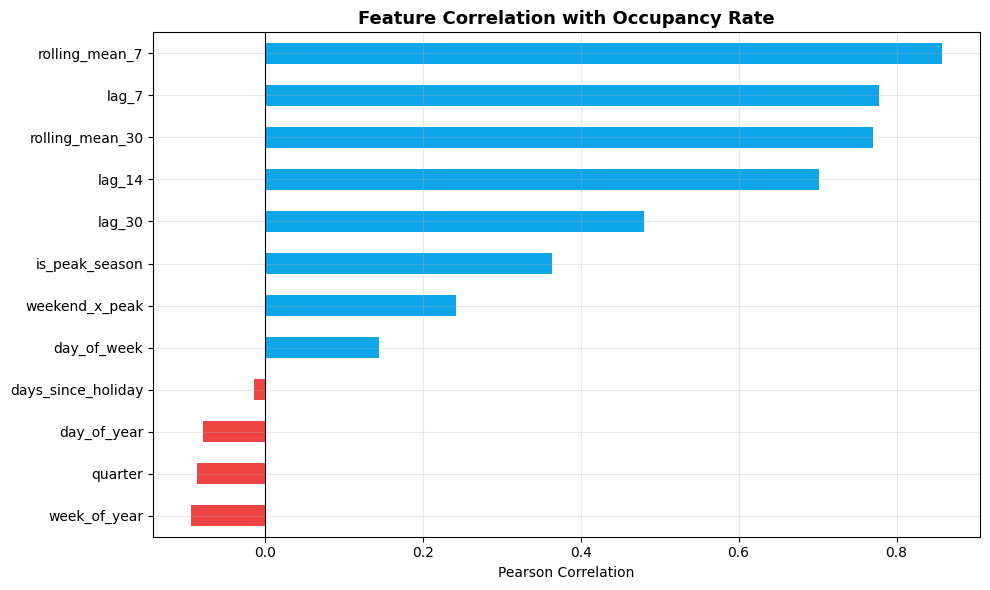


Top 5 most correlated features:
rolling_mean_7     0.858093
lag_7              0.777884
rolling_mean_30    0.770293
lag_14             0.702447
lag_30             0.480346
Name: occupancy_rate, dtype: float64


In [4]:
# Correlation of new features with occupancy_rate
feature_cols = [
    'occupancy_rate', 'day_of_week', 'day_of_year', 'week_of_year',
    'quarter', 'is_peak_season', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30', 'weekend_x_peak', 'days_since_holiday',
]
corr = df[feature_cols].corr()['occupancy_rate'].drop('occupancy_rate').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#ef4444' if v < 0 else '#0ea5e9' for v in corr]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Occupancy Rate', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('../docs/figures/03_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most correlated features:')
print(corr.abs().sort_values(ascending=False).head())

In [5]:
# Save feature-engineered dataset
df_feat = df.dropna(subset=['lag_30', 'rolling_mean_30'])
df_feat.to_csv('../data/splits/features.csv')
print(f'Feature-engineered dataset saved: {df_feat.shape}')
df_feat[feature_cols].describe()

Feature-engineered dataset saved: (1066, 20)


,occupancy_rate,day_of_week,day_of_year,week_of_year,quarter,is_peak_season,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,weekend_x_peak,days_since_holiday
count,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000
mean,0.627214,2.997186,187.885553,27.078799,2.550657,0.146341,0.626520,0.626454,0.627026,0.626798,0.626753,0.040338,16.999062
std,0.201564,2.000233,103.101208,14.725704,1.103883,0.353614,0.201037,0.201002,0.201693,0.181740,0.169868,0.196842,14.556769
min,0.130000,0.000000,1.000000,1.000000,1.000000,0.000000,0.130000,0.130000,0.130000,0.275714,0.329000,0.000000,0.000000
25%,0.470000,1.000000,99.250000,14.000000,2.000000,0.000000,0.470000,0.470000,0.470000,0.430000,0.491750,0.000000,5.000000
50%,0.670000,3.000000,188.000000,27.000000,3.000000,0.000000,0.670000,0.670000,0.670000,0.648571,0.634000,0.000000,13.000000
75%,0.800000,5.000000,277.000000,40.000000,4.000000,0.000000,0.800000,0.800000,0.800000,0.790000,0.784333,0.000000,26.000000
max,1.000000,6.000000,366.000000,52.000000,4.000000,1.000000,1.000000,1.000000,1.000000,0.858571,0.827000,1.000000,63.000000


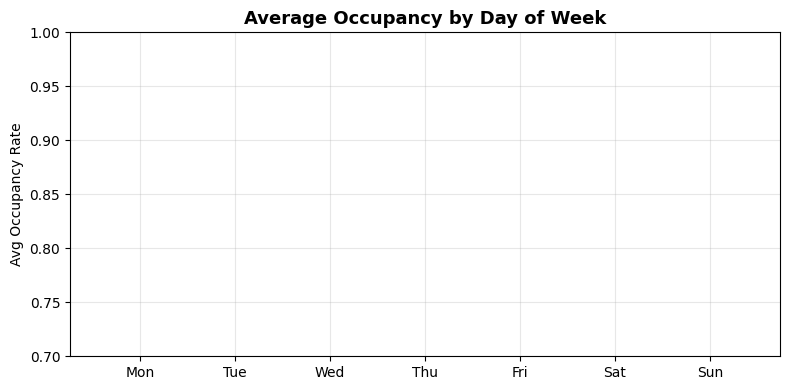

Day of week averages:
  Mon: 0.615 (61.5%)
  Tue: 0.602 (60.2%)
  Wed: 0.613 (61.3%)
  Thu: 0.607 (60.7%)
  Fri: 0.599 (59.9%)
  Sat: 0.688 (68.8%)
  Sun: 0.699 (69.9%)


In [6]:
# Weekly occupancy pattern
dow_avg = df.groupby('day_of_week')['occupancy_rate'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(8, 4))
plt.bar(dow_labels, dow_avg.values, color='#0ea5e9', alpha=0.8)
plt.title('Average Occupancy by Day of Week', fontsize=13, fontweight='bold')
plt.ylabel('Avg Occupancy Rate')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.savefig('../docs/figures/03_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

print('Day of week averages:')
for i, (label, val) in enumerate(zip(dow_labels, dow_avg)):
    print(f'  {label}: {val:.3f} ({val*100:.1f}%)')